# Analyze and compare

In [1]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage
import skimage.io
import tifffile

import time
import torch
import torch.hub
import torch.nn


/project/DPDS/Xiao_lab/shared/qin_zhou/environments/envs/MicNet/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1) Load data

In [3]:
feat_images, feat_genes = torch.load("./output/Dataset_MERFISH/3_IGC_mouse_hypothalamus_all_indexes_features.pt")

image_feature = feat_images
gene_feature = feat_genes

In [ ]:
transformation_file = "./Sample_data/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_v2.csv"
pd_meta = pd.read_table(transformation_file, index_col=0, sep=",")
pd_meta.loc[:, 'Centroid_X'] *= 4
pd_meta.loc[:, 'Centroid_Y'] *= 4
print(pd_meta.shape)


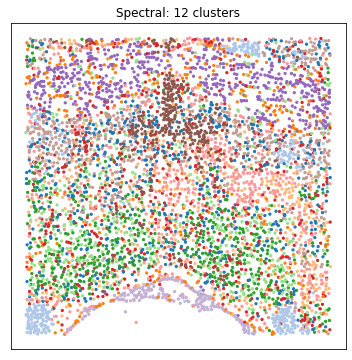

In [13]:
from sklearn.cluster import SpectralClustering
indexes_all = pd_meta.index.values
coords_x = pd_meta.loc[indexes_all, "Centroid_X"].values
coords_y = pd_meta.loc[indexes_all, "Centroid_Y"].values
cluster_df = pd.DataFrame(index=pd_meta.index.values)
for n_clusters in [12]:
    # Image feature
    X = image_feature.copy()
    X_filter = X[np.logical_not(np.any(np.isnan(X), 1)), :]

    method = SpectralClustering(n_clusters=n_clusters, random_state=0)
    name = "Spectral"
    model = method.fit(X_filter)
    Y = np.zeros([X.shape[0]])
    Y[:] = np.nan
    Y[np.logical_not(np.any(np.isnan(X), 1))] = model.labels_
    Y_image = Y.copy()
    
    cluster_df.loc[:, "imagefeature_{}_clusters".format(n_clusters)] = [int(_) for _ in Y]
    
    # Genomic feature
    X = gene_feature.copy()
    X_filter = X[np.logical_not(np.any(np.isnan(X), 1)), :]

    method = SpectralClustering(n_clusters=n_clusters, random_state=0)
    name = "Spectral"
    model = method.fit(X_filter)
    Y = np.zeros([X.shape[0]])
    Y[:] = np.nan
    Y[np.logical_not(np.any(np.isnan(X), 1))] = model.labels_

    # Match cluster from Y to Y_image
    Y_gene = Y.copy()
    Y = np.zeros_like(Y)
    Y[:] = np.nan
    matched_clusters = set()
    # Sort clusters from matched ratio high to low
    to_matched_clusters = np.argsort([np.max([np.sum(Y_image[Y_gene == to_matched_cluster] == _)/\
                                              np.sum(Y_gene == to_matched_cluster)
                                              for _ in range(n_clusters)])
                                      for to_matched_cluster in range(n_clusters)])[::-1]  
    # to_matched_clusters = np.argsort(np.bincount(Y_gene.astype(int)))[::-1]  # Sort clusters from big to small
    for to_matched_cluster in to_matched_clusters:
        corresponding_image_clusters = np.argsort([np.sum(Y_image[Y_gene == to_matched_cluster] == _) for _ in range(n_clusters)])[::-1]
        for corresponding_image_cluster in corresponding_image_clusters:
            if corresponding_image_cluster not in matched_clusters:
                # print(to_matched_cluster, corresponding_image_cluster)
                Y[Y_gene == to_matched_cluster] = corresponding_image_cluster
                matched_clusters = matched_clusters | set([corresponding_image_cluster])
                break

    cluster_df.loc[:, "genomicfeature_{}_clusters".format(n_clusters)] = [int(_) for _ in Y]
    
    # Combined feature
    X = np.concatenate((image_feature, gene_feature), axis=1)
    X_filter = X[np.logical_not(np.any(np.isnan(X), 1)), :]

    method = SpectralClustering(n_clusters=n_clusters, random_state=0)
    name = "Spectral"
    model = method.fit(X_filter)
    Y = np.zeros([X.shape[0]])
    Y[:] = np.nan
    Y[np.logical_not(np.any(np.isnan(X), 1))] = model.labels_

    # Match cluster from Y to Y_image
    Y_gene = Y.copy()
    Y = np.zeros_like(Y)
    Y[:] = np.nan
    matched_clusters = set()
    # Sort clusters from matched ratio high to low
    to_matched_clusters = np.argsort([np.max([np.sum(Y_image[Y_gene == to_matched_cluster] == _)/\
                                              np.sum(Y_gene == to_matched_cluster)
                                              for _ in range(n_clusters)])
                                      for to_matched_cluster in range(n_clusters)])[::-1]  
    # to_matched_clusters = np.argsort(np.bincount(Y_gene.astype(int)))[::-1]  # Sort clusters from big to small
    for to_matched_cluster in to_matched_clusters:
        corresponding_image_clusters = np.argsort([np.sum(Y_image[Y_gene == to_matched_cluster] == _) for _ in range(n_clusters)])[::-1]
        for corresponding_image_cluster in corresponding_image_clusters:
            if corresponding_image_cluster not in matched_clusters:
                # print(to_matched_cluster, corresponding_image_cluster)
                Y[Y_gene == to_matched_cluster] = corresponding_image_cluster
                matched_clusters = matched_clusters | set([corresponding_image_cluster])
                break
                
    # Set color
    if n_clusters <= 10:
        cmap = plt.get_cmap("tab10")
    else:
        cmap = plt.get_cmap("tab20")
    _mycolor = [cmap(int(_)) for _ in Y]

    plt.figure(figsize=(6, 6))
    # plt.subplot(122)
    # plt.imshow(image_norm)
    fig = plt.scatter(coords_x, coords_y, c=_mycolor, s=5)
    plt.title('{}: {} clusters'.format(name, n_clusters))
    # plt.axis('off')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    # plt.xlim(xmin, xmax)
    # plt.ylim(ymax, ymin)
    plt.show()
    
    cluster_df.loc[:, "combinedfeature_{}_clusters".format(n_clusters)] = [int(_) for _ in Y]

In [14]:
combined_cluster_df=cluster_df.copy()

In [16]:
combined_cluster_df

,imagefeature_12_clusters,genomicfeature_12_clusters,combinedfeature_12_clusters
2,1,11,1
3,1,4,1
4,1,4,1
5,1,11,1
6,1,4,1
...,...,...,...
5552,2,1,8
5553,2,8,8
5554,3,3,11
5555,11,11,11


50


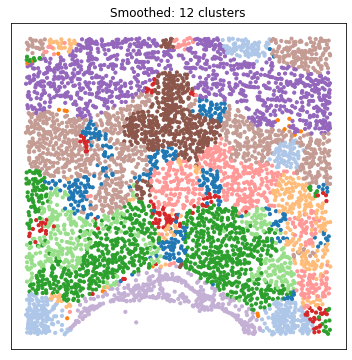

In [18]:
from sklearn.neighbors import NearestNeighbors
from sklearn import neighbors

n_neighbors = 50
print(n_neighbors)
X = np.array(pd_meta.loc[:, ['Centroid_X', 'Centroid_Y']].values)
# nbrs = NearestNeighbors(n_neighbors=8, algorithm='ball_tree').fit(X)
# distances, indices = nbrs.kneighbors(X)
for n_clusters in [12]:
    Y = combined_cluster_df.loc[:, 'combinedfeature_{}_clusters'.format(n_clusters)].values
    # for i, index in enumerate(combined_cluster_df.index.values):
        # y = Y[indices[i, :]]
    
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights='uniform')
    clf.fit(X, Y)
    combined_cluster_df.loc[:, 'combinedfeature_{}_clusters_smoothed'.format(n_clusters)] = clf.predict(X)

    # Combined_feature_smoothed
    plt.figure(figsize=(6, 6))
    Y = combined_cluster_df.loc[:, "combinedfeature_{}_clusters_smoothed".format(n_clusters)].values.copy()
    # Set color
    if n_clusters <= 10:
        cmap = plt.get_cmap("tab10")
    else:
        cmap = plt.get_cmap("tab20")
    _mycolor = [cmap(int(_)) for _ in Y]
    fig = plt.scatter(coords_x, coords_y, c=_mycolor, s=10)
    plt.title('Smoothed: {} clusters'.format(n_clusters))
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    # plt.xlim(xmin, xmax)
    # plt.ylim(ymax, ymin)
    plt.show()

# Read Ground Truth

In [25]:
GT_raw=pd.read_csv("./Sample_data/Dataset_MERFISH/Ground_truth.csv", index_col=0)
GT_raw

,annotation_region
2,VLPO
3,VLPO
4,VLPO
5,VLPO
6,VLPO
...,...
5552,ACA
5553,ACA
5554,BNST
5555,BNST


In [30]:
from sklearn import metrics
import pandas as pd

cluster_name = 'combinedfeature_12_clusters_smoothed'

# Select valid indices (no NaN in cluster or annotation)
selected_index = [
    idx for idx in combined_cluster_df.index
    if pd.notna(combined_cluster_df.loc[idx, 'annotation_region']) and 
       pd.notna(combined_cluster_df.loc[idx, cluster_name])
]

# Extract the two label vectors
pred = combined_cluster_df.loc[selected_index, cluster_name]
gt   = combined_cluster_df.loc[selected_index, 'annotation_region']

# Compute ARI and AMI
ari = metrics.adjusted_rand_score(gt, pred)
ami = metrics.adjusted_mutual_info_score(gt, pred)

print("ARI =", ari)
print("AMI =", ami)


ARI = 0.4465984923883513
AMI = 0.5614976944443263
